# GeneGuard: AI-Powered Diabetes Prediction System

Author: Prajwal Biradar

This project predicts diabetes risk using Machine Learning.
Dataset used: PIMA Indians Diabetes Dataset

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Upload Dataset

In [4]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [5]:
import pandas as pd

data = pd.read_csv("diabetes.csv")

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Dataset Information

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Dataset Statistics

In [7]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
data.shape

(768, 9)

## Diabetes Outcome Distribution

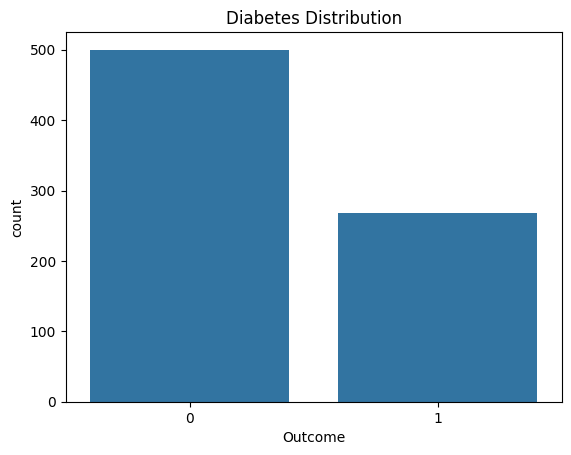

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Outcome", data=data)
plt.title("Diabetes Distribution")
plt.show()

## Feature Correlation Heatmap

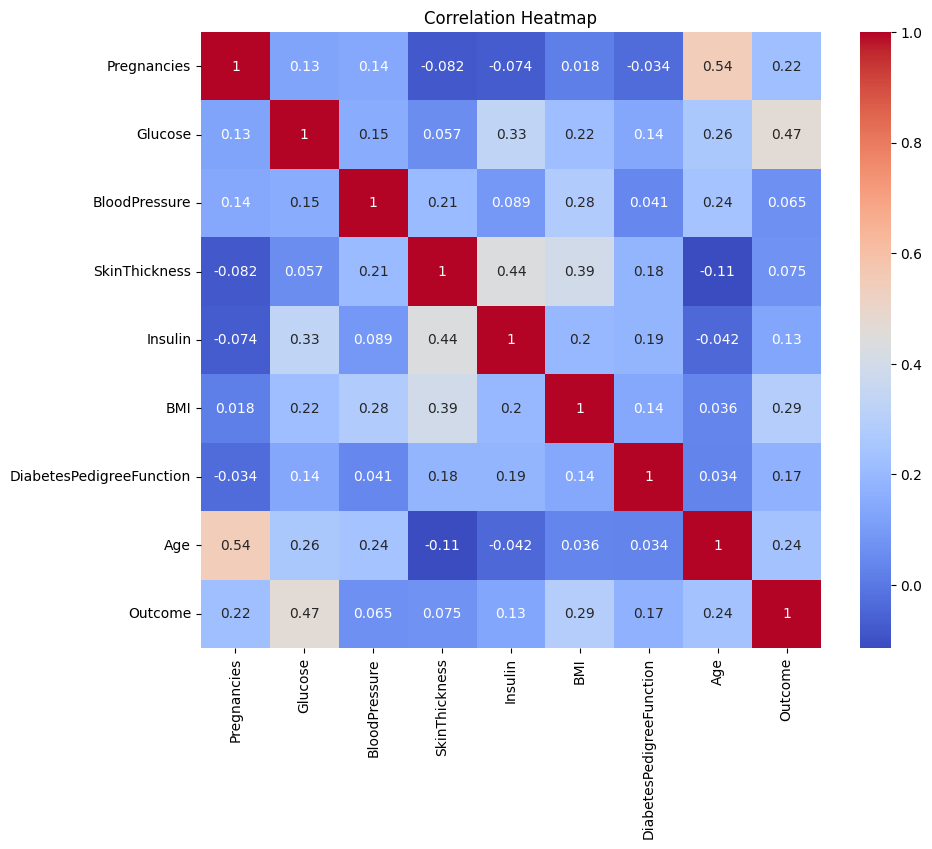

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Feature and Target Split

In [11]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

## Train Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Machine Learning Model

In [13]:
from sklearn.ensemble import RandomForestClassifier

In [14]:
model = RandomForestClassifier()

In [15]:
model.fit(X_train, y_train)

RandomForestClassifier()

## Model Prediction

In [16]:
predictions = model.predict(X_test)

## Model Accuracy

In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7597402597402597


## Confusion Matrix

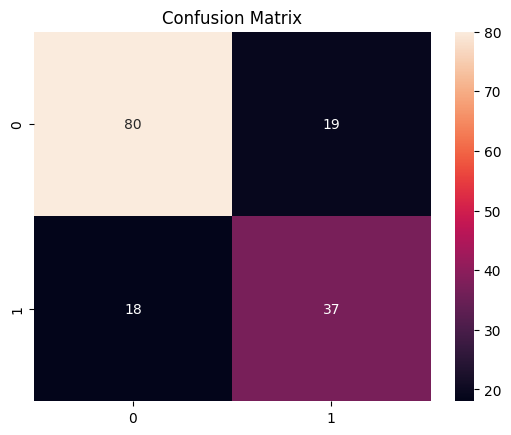

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.82      0.81      0.81        99
           1       0.66      0.67      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



## Test Prediction for New Patient

In [21]:
sample = [[2,120,70,20,79,25.5,0.5,33]]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("High Risk of Diabetes")
else:
    print("Low Risk of Diabetes")

Low Risk of Diabetes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## Feature Importance

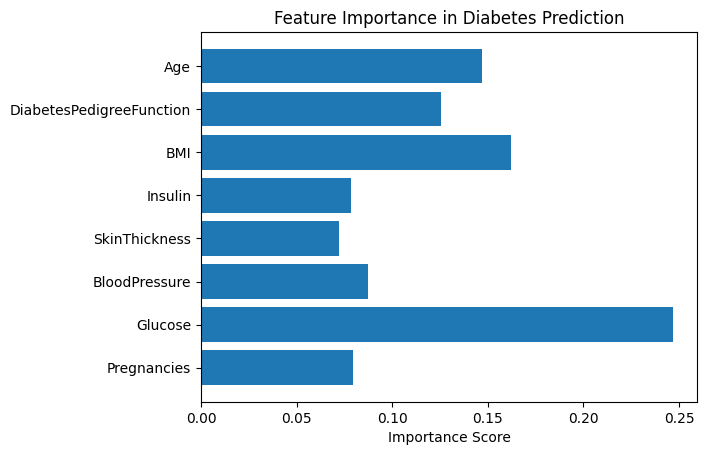

In [22]:
importance = model.feature_importances_
features = X.columns

import matplotlib.pyplot as plt

plt.barh(features, importance)
plt.title("Feature Importance in Diabetes Prediction")
plt.xlabel("Importance Score")
plt.show()

## Save the Model

In [24]:
import pickle

pickle.dump(model, open("diabetes_model.pkl", "wb"))

In [25]:
from google.colab import files
files.download("diabetes_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

In this project, a Machine Learning model was developed to predict diabetes using the PIMA Indians Diabetes Dataset.
The Random Forest Classifier achieved good prediction accuracy and helped identify important health parameters such as glucose level, BMI, and age.
This system can assist in early detection of diabetes risk and support healthcare decision-making.